## Amazon Inc. (AMZN) — Technical Analysis

### Overview
This notebook performs technical analysis on **Amazon Inc. (AMZN)** stock price data using industry-standard indicators. The analysis covers moving averages, Bollinger Bands, momentum indicators, volatility metrics, time series decomposition, and stationarity analysis.

### Objectives
- Load and validate AMZN historical stock price data
- Compute technical indicators using TA-Lib and PyNance
- Visualize price trends with overlaid technical indicators
- Analyze momentum, volatility, and time series properties
- Compute quantitative performance metrics

### Dataset
The analysis uses historical AMZN stock price data containing Open, High, Low, Close, and Volume (OHLCV) data.

### Understanding Stock Market Data
Before diving into analysis, let's define the standard columns in our dataset:

- **Open:** The price at the start of the trading day
- **High:** The maximum price reached during the day
- **Low:** The minimum price reached during the day
- **Close:** The final price when the market closed — primary price for technical indicators
- **Volume:** The total number of shares traded during the period

## 1. Environment Setup & Library Imports

In [1]:
# Fix PyNance compatibility with modern pandas_datareader
import pandas.util._decorators as _dec

def _patched_deprecate_kwarg(*args, **kwargs):
    if len(args) == 2 and isinstance(args[0], str):
        return _original_deprecate_kwarg(FutureWarning, args[0], args[1], **kwargs)
    return _original_deprecate_kwarg(*args, **kwargs)

if not hasattr(_dec, '_original_deprecate_kwarg'):
    _original_deprecate_kwarg = _dec.deprecate_kwarg
    _dec.deprecate_kwarg = _patched_deprecate_kwarg

import pynance as pn
print("✅ PyNance imported successfully!")

✅ PyNance imported successfully!


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock_data
from src.analysis import (
    compute_sma,
    compute_ema,
    compute_rsi,
    compute_macd,
    compute_bollinger_bands,
    get_daily_return,
    check_stationarity
)

# Global plot settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"TA-Lib version : {talib.__version__}")
print("✅ All libraries imported successfully!")

TA-Lib version : 0.6.8
✅ All libraries imported successfully!


## 2. Load & Clean Stock Price Data

We load the AMZN historical stock price dataset using our modular `load_stock_data()` function from `src/data_loader.py`. This enforces correct data types, sorts by date, and handles missing values automatically.

In [3]:
amzn = load_stock_data('../data/raw/AMZN.csv')

print(f"Dataset Shape: {amzn.shape}")
print(f"\nColumn Names: {amzn.columns.tolist()}")
print(f"\nDate range: {amzn['Date'].min().date()} to {amzn['Date'].max().date()}")
print(f"Total trading days: {len(amzn)}")
amzn.head()

✅ Loaded 3774 rows. No missing values.
Dataset Shape: (3774, 6)

Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2009-01-02 to 2023-12-29
Total trading days: 3774


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000.0
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000.0
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000.0
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000.0
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000.0


## 3. Moving Averages (SMA & EMA)

Moving averages smooth out price data to identify trends:
- **SMA (Simple Moving Average)** — equal weight to all periods
- **EMA (Exponential Moving Average)** — more weight to recent prices



**Interpretation:**
- **Golden Cross:** Short-term MA crosses above long-term MA → bullish signal
- **Death Cross:** Short-term MA crosses below long-term MA → bearish signal

In [4]:
amzn['SMA_20'] = compute_sma(amzn['Close'], 20)
amzn['SMA_50'] = compute_sma(amzn['Close'], 50)
amzn['EMA_20'] = compute_ema(amzn['Close'], 20)
amzn['EMA_50'] = compute_ema(amzn['Close'], 50)

print("✅ Moving averages computed successfully!")
print(amzn[['Date', 'Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail(10))

✅ Moving averages computed successfully!
           Date       Close      SMA_20    SMA_50      EMA_20      EMA_50
3764 2023-12-15  149.970001  146.650000  138.8954  145.895513  141.334179
3765 2023-12-18  154.070007  147.094501  139.4176  146.674036  141.833623
3766 2023-12-19  153.789993  147.477500  139.9282  147.351746  142.302501
3767 2023-12-20  152.119995  147.888500  140.3810  147.805865  142.687500
3768 2023-12-21  153.839996  148.245000  140.8212  148.380545  143.124853
3769 2023-12-22  153.419998  148.578999  141.2430  148.860492  143.528584
3770 2023-12-26  153.410004  148.863000  141.7154  149.293779  143.916091
3771 2023-12-27  153.339996  149.178500  142.1312  149.679133  144.285656
3772 2023-12-28  153.380005  149.531499  142.5694  150.031597  144.642297
3773 2023-12-29  151.940002  149.824000  143.0456  150.213350  144.928482


### 3.1 Moving Averages Visualization

The chart below shows AMZN closing prices overlaid with 20-day and 50-day SMA and EMA. When the short-term average crosses above the long-term average it signals a potential **buy opportunity**, and vice versa.

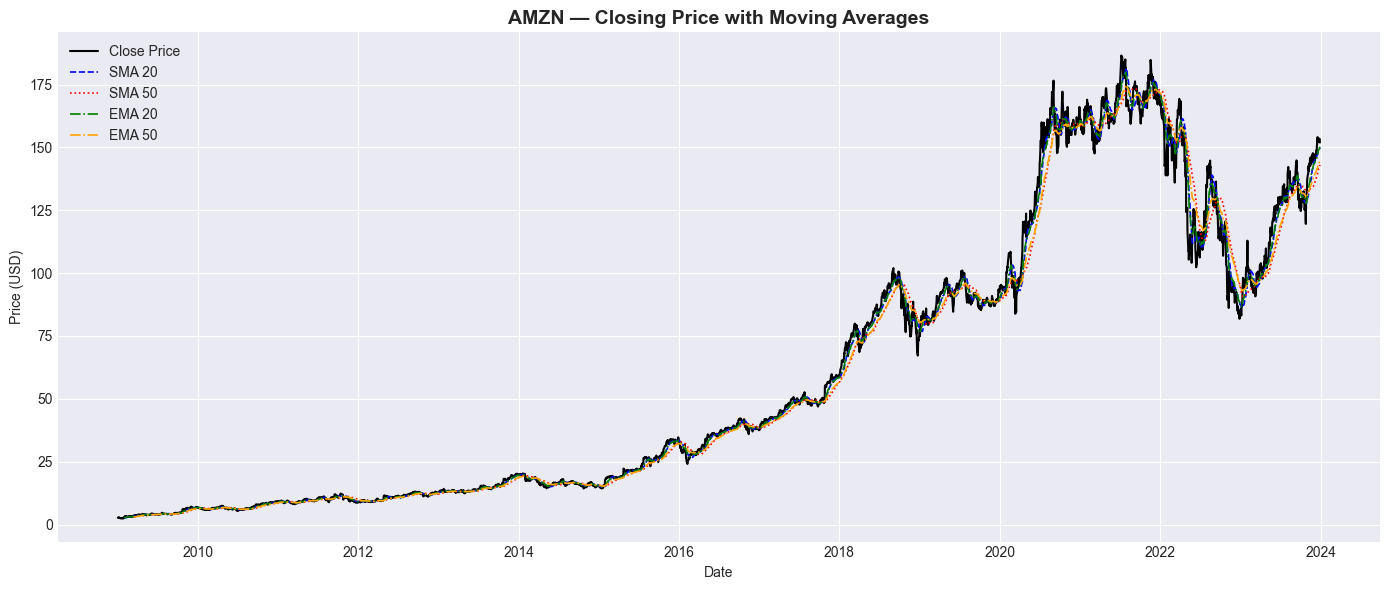

✅ Moving averages plot rendered!


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(amzn['Date'], amzn['Close'], label='Close Price', color='black', linewidth=1.5)
ax.plot(amzn['Date'], amzn['SMA_20'], label='SMA 20', color='blue', linewidth=1.2, linestyle='--')
ax.plot(amzn['Date'], amzn['SMA_50'], label='SMA 50', color='red', linewidth=1.2, linestyle=':')
ax.plot(amzn['Date'], amzn['EMA_20'], label='EMA 20', color='green', linewidth=1.2, linestyle='-.')
ax.plot(amzn['Date'], amzn['EMA_50'], label='EMA 50', color='orange', linewidth=1.2, linestyle='-.')

ax.set_title('AMZN — Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Moving averages plot rendered!")

## 4. Bollinger Bands

Bollinger Bands consist of:
- **Middle Band** — 20-day SMA
- **Upper Band** — Middle Band + 2 standard deviations
- **Lower Band** — Middle Band - 2 standard deviations

Price touching the upper band suggests **overbought** conditions while touching the lower band suggests **oversold** conditions.

In [6]:
amzn['BB_Upper'], amzn['BB_Middle'], amzn['BB_Lower'] = compute_bollinger_bands(
    amzn['Close'])

print("✅ Bollinger Bands computed successfully!")
print(amzn[['Date', 'Close', 'BB_Upper', 'BB_Middle', 'BB_Lower']].tail(10))

✅ Bollinger Bands computed successfully!
           Date       Close    BB_Upper   BB_Middle    BB_Lower
3764 2023-12-15  149.970001  149.409450  146.650000  143.890550
3765 2023-12-18  154.070007  151.266234  147.094501  142.922768
3766 2023-12-19  153.789993  152.536796  147.477500  142.418204
3767 2023-12-20  152.119995  153.052959  147.888500  142.724041
3768 2023-12-21  153.839996  153.986912  148.245000  142.503087
3769 2023-12-22  153.419998  154.696716  148.578999  142.461283
3770 2023-12-26  153.410004  155.314929  148.863000  142.411071
3771 2023-12-27  153.339996  155.854273  149.178500  142.502726
3772 2023-12-28  153.380005  156.311164  149.531499  142.751835
3773 2023-12-29  151.940002  156.488309  149.824000  143.159691


### 4.1 Bollinger Bands Visualization

The shaded region between the upper and lower bands represents the expected price range. Prices outside this range signal potential reversals.

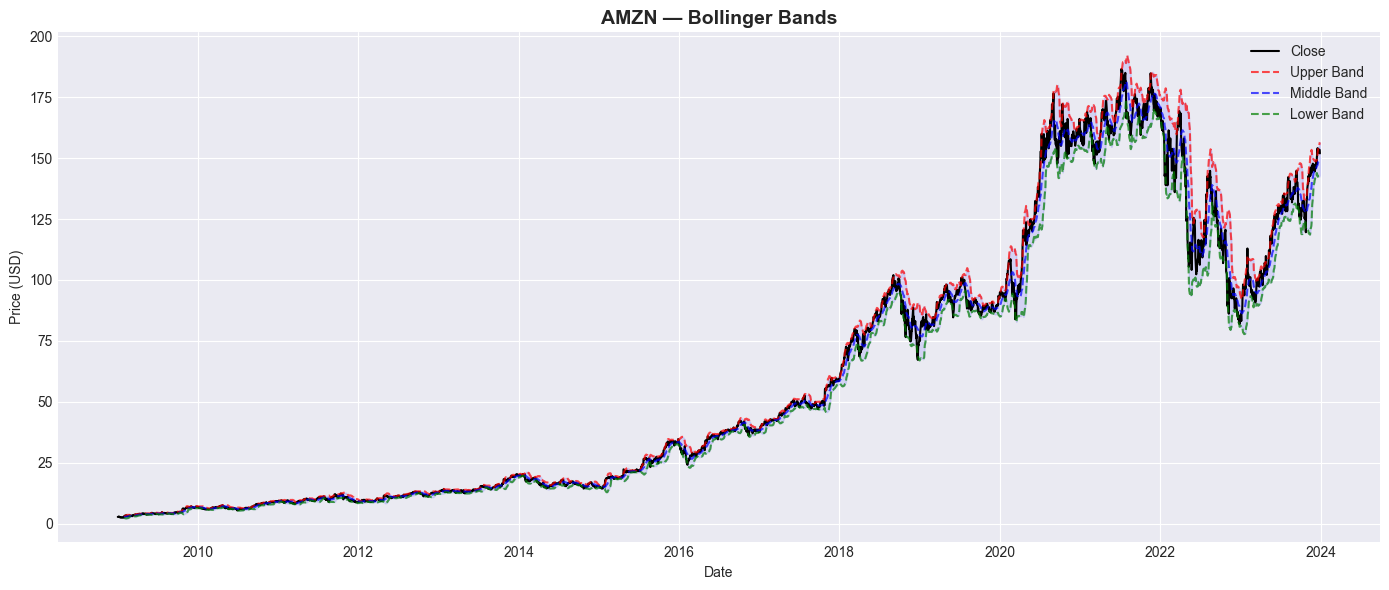

✅ Bollinger Bands plot rendered!


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(amzn['Date'], amzn['Close'], label='Close', color='black', linewidth=1.5)
ax.plot(amzn['Date'], amzn['BB_Upper'], label='Upper Band', color='red',
        linestyle='--', alpha=0.7)
ax.plot(amzn['Date'], amzn['BB_Middle'], label='Middle Band', color='blue',
        linestyle='--', alpha=0.7)
ax.plot(amzn['Date'], amzn['BB_Lower'], label='Lower Band', color='green',
        linestyle='--', alpha=0.7)
ax.fill_between(amzn['Date'], amzn['BB_Upper'], amzn['BB_Lower'],
                alpha=0.1, color='blue')

ax.set_title('AMZN — Bollinger Bands', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Bollinger Bands plot rendered!")

## 5. RSI (Relative Strength Index)

RSI is a **momentum oscillator** that measures the speed and change of price movements:
- **RSI >= 70** — Overbought: potential sell signal
- **RSI <= 30** — Oversold: potential buy signal
- **RSI = 50** — Neutral momentum

We use the standard 14-day period.

In [8]:
amzn['RSI'] = compute_rsi(amzn['Close'])

print("✅ RSI computed successfully!")
print(amzn[['Date', 'Close', 'RSI']].tail(10))

✅ RSI computed successfully!
           Date       Close        RSI
3764 2023-12-15  149.970001  62.090387
3765 2023-12-18  154.070007  68.053721
3766 2023-12-19  153.789993  67.275369
3767 2023-12-20  152.119995  62.671579
3768 2023-12-21  153.839996  65.305020
3769 2023-12-22  153.419998  64.115558
3770 2023-12-26  153.410004  64.085644
3771 2023-12-27  153.339996  63.860893
3772 2023-12-28  153.380005  63.938728
3773 2023-12-29  151.940002  59.012257


## 6. MACD (Moving Average Convergence Divergence)

MACD identifies momentum shifts and trend reversals:
- **MACD Line** — difference between 12-day and 26-day EMA
- **Signal Line** — 9-day EMA of the MACD line
- **Histogram** — difference between MACD and Signal line

- **Bullish Crossover:** MACD crosses above Signal → buy signal
- **Bearish Crossover:** MACD crosses below Signal → sell signal
- **Divergence:** Price makes new high but MACD does not → trend weakening

In [9]:
amzn['MACD'], amzn['MACD_Signal'], amzn['MACD_Hist'] = compute_macd(
    amzn['Close'])

print("✅ MACD computed successfully!")
print(amzn[['Date', 'Close', 'MACD', 'MACD_Signal', 'MACD_Hist']].tail(10))

✅ MACD computed successfully!
           Date       Close      MACD  MACD_Signal  MACD_Hist
3764 2023-12-15  149.970001  2.357466     2.554335  -0.196869
3765 2023-12-18  154.070007  2.731655     2.589799   0.141856
3766 2023-12-19  153.789993  2.971356     2.666110   0.305245
3767 2023-12-20  152.119995  2.992074     2.731303   0.260771
3768 2023-12-21  153.839996  3.111417     2.807326   0.304091
3769 2023-12-22  153.419998  3.135958     2.873052   0.262905
3770 2023-12-26  153.410004  3.118650     2.922172   0.196478
3771 2023-12-27  153.339996  3.063965     2.950530   0.113434
3772 2023-12-28  153.380005  2.989395     2.958303   0.031092
3773 2023-12-29  151.940002  2.782032     2.923049  -0.141017


### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

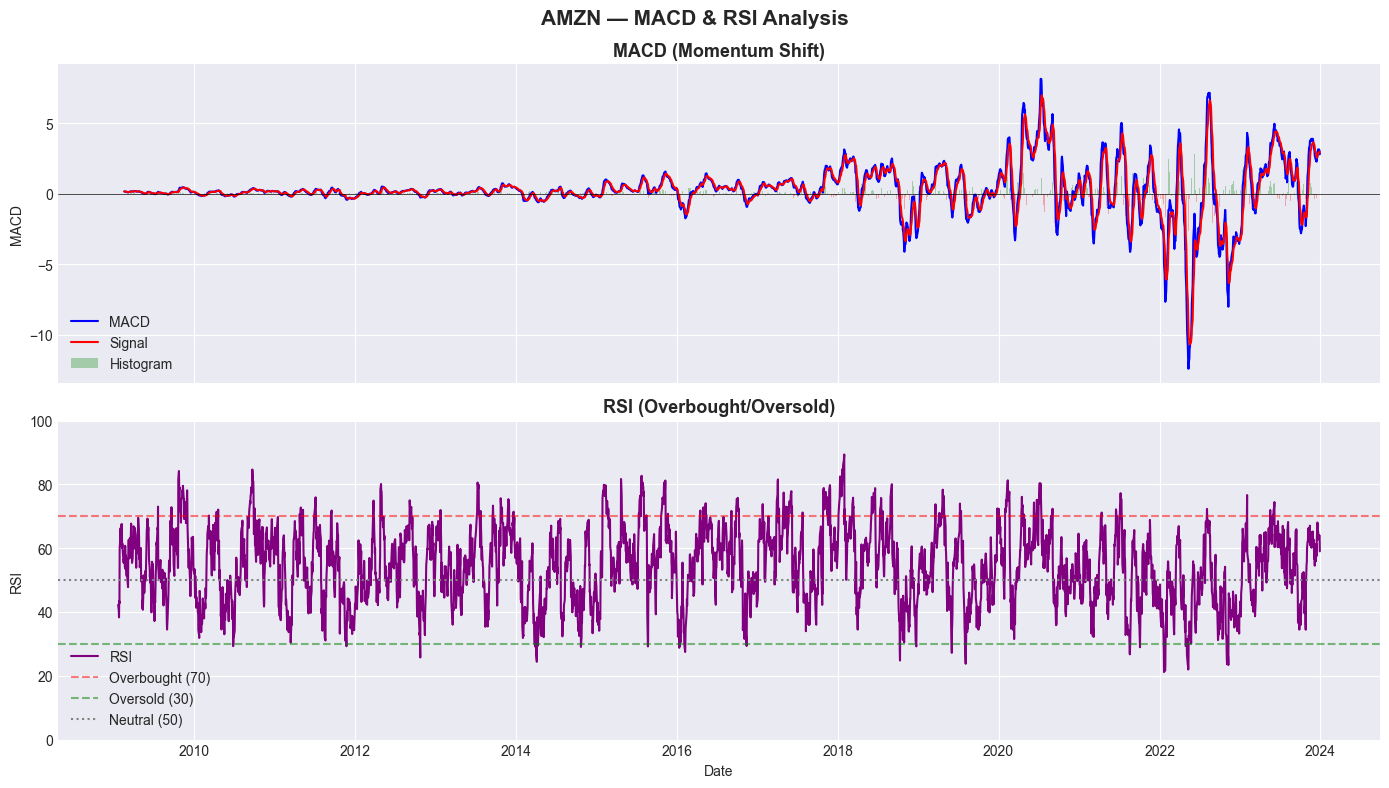

✅ MACD & RSI plot rendered!


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(amzn['Date'], amzn['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(amzn['Date'], amzn['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(amzn['Date'], amzn['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in amzn['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(amzn['Date'], amzn['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('AMZN — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

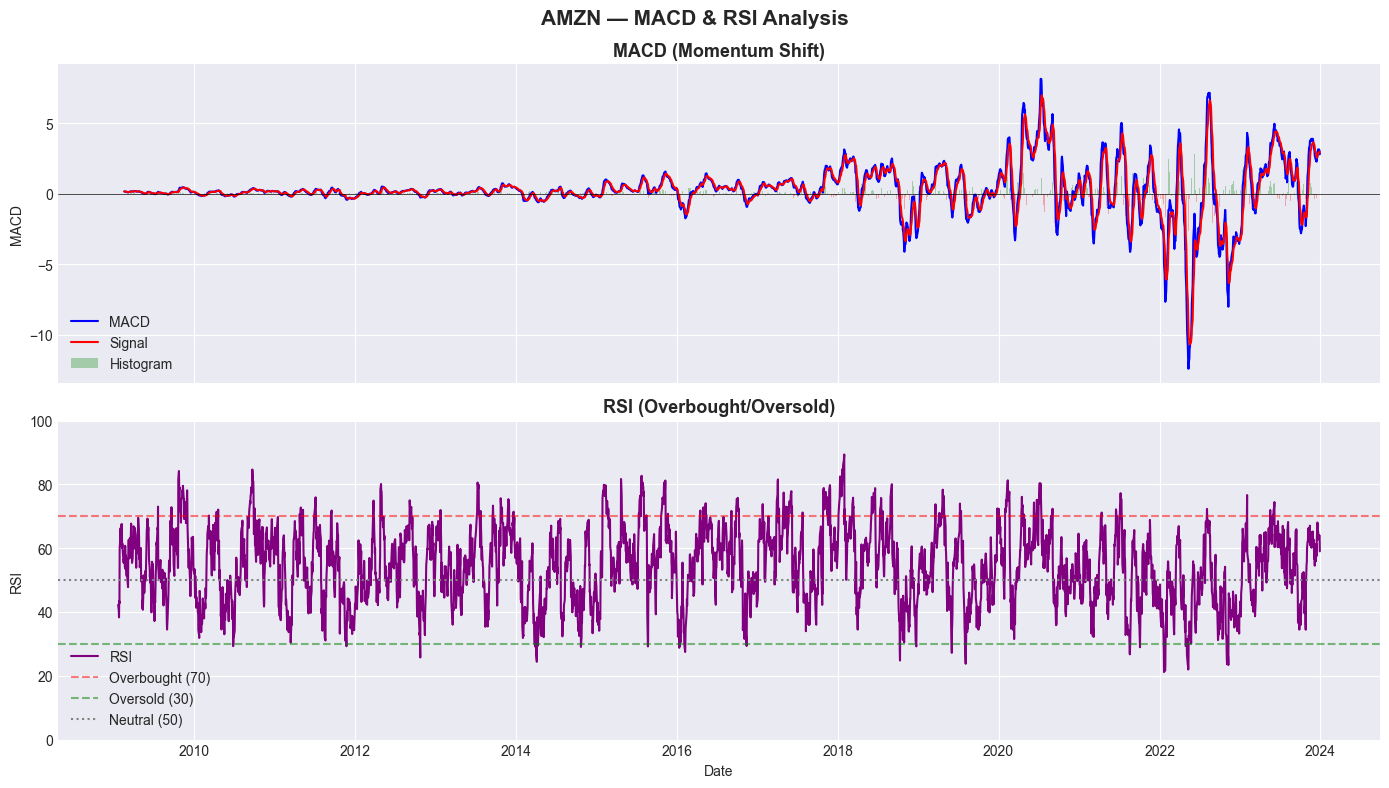

✅ MACD & RSI plot rendered!


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(amzn['Date'], amzn['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(amzn['Date'], amzn['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(amzn['Date'], amzn['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in amzn['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(amzn['Date'], amzn['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('AMZN — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

## 7. PyNance Technical Indicators

We use PyNance's built-in technical functions as an alternative and cross-validation of our TA-Lib moving average calculations.

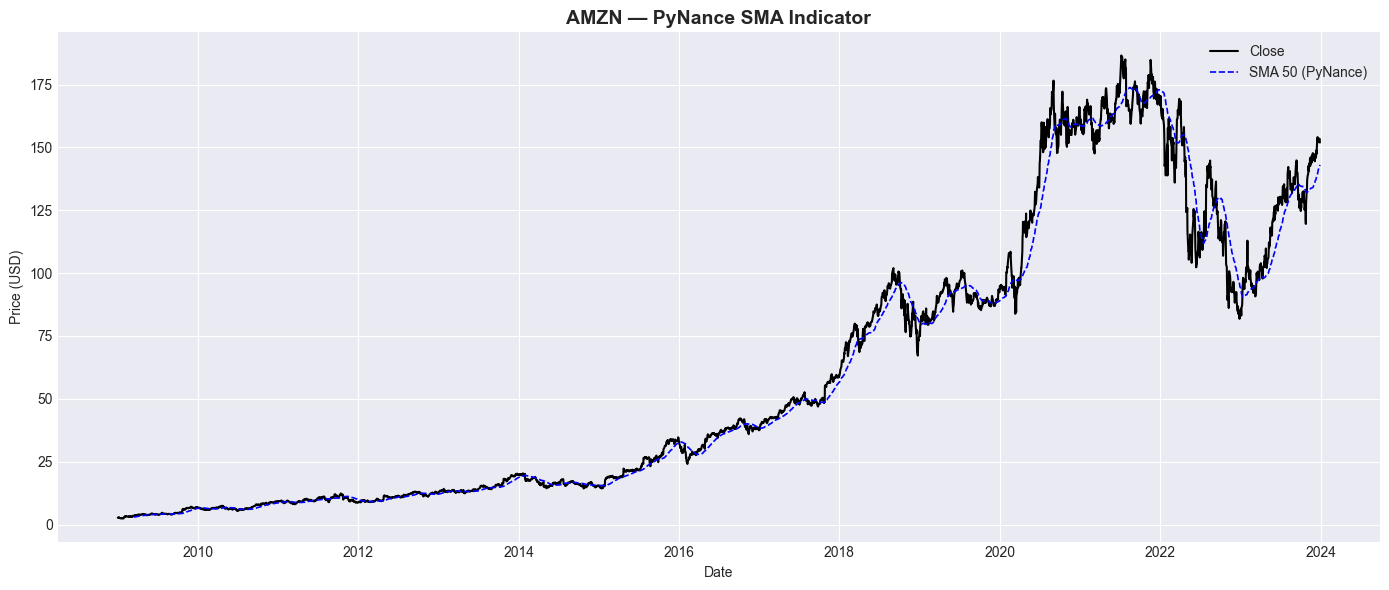

✅ PyNance SMA computed and plotted successfully!


In [12]:
try:
    amzn['SMA_50_pn'] = pn.tech.sma(amzn['Close'], window=50)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(amzn['Date'], amzn['Close'], label='Close', color='black', linewidth=1.5)
    ax.plot(amzn['Date'], amzn['SMA_50_pn'], label='SMA 50 (PyNance)',
            color='blue', linewidth=1.2, linestyle='--')
    ax.set_title('AMZN — PyNance SMA Indicator', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("✅ PyNance SMA computed and plotted successfully!")
except Exception as e:
    print(f"PyNance error: {e}")

## 8. Daily Returns & Volatility

We compute daily percentage returns and 20-day rolling volatility to understand amzn's risk profile during the analysis period.

In [13]:
amzn['Returns'] = get_daily_return(amzn['Close'])
amzn['Volatility_20'] = amzn['Returns'].rolling(window=20).std()

print("✅ Daily returns and volatility computed!")
print(f"\nAverage Daily Return : {amzn['Returns'].mean():.4f}")
print(f"Daily Return Std Dev : {amzn['Returns'].std():.4f}")
print(f"Max Daily Gain       : {amzn['Returns'].max():.4f}")
print(f"Max Daily Loss       : {amzn['Returns'].min():.4f}")

✅ Daily returns and volatility computed!

Average Daily Return : 0.0013
Daily Return Std Dev : 0.0218
Max Daily Gain       : 0.2680
Max Daily Loss       : -0.1405


### 8.1 Daily Returns & Volatility Visualization

The charts below show AMZN's daily returns and 20-day rolling volatility, highlighting periods of elevated market uncertainty.

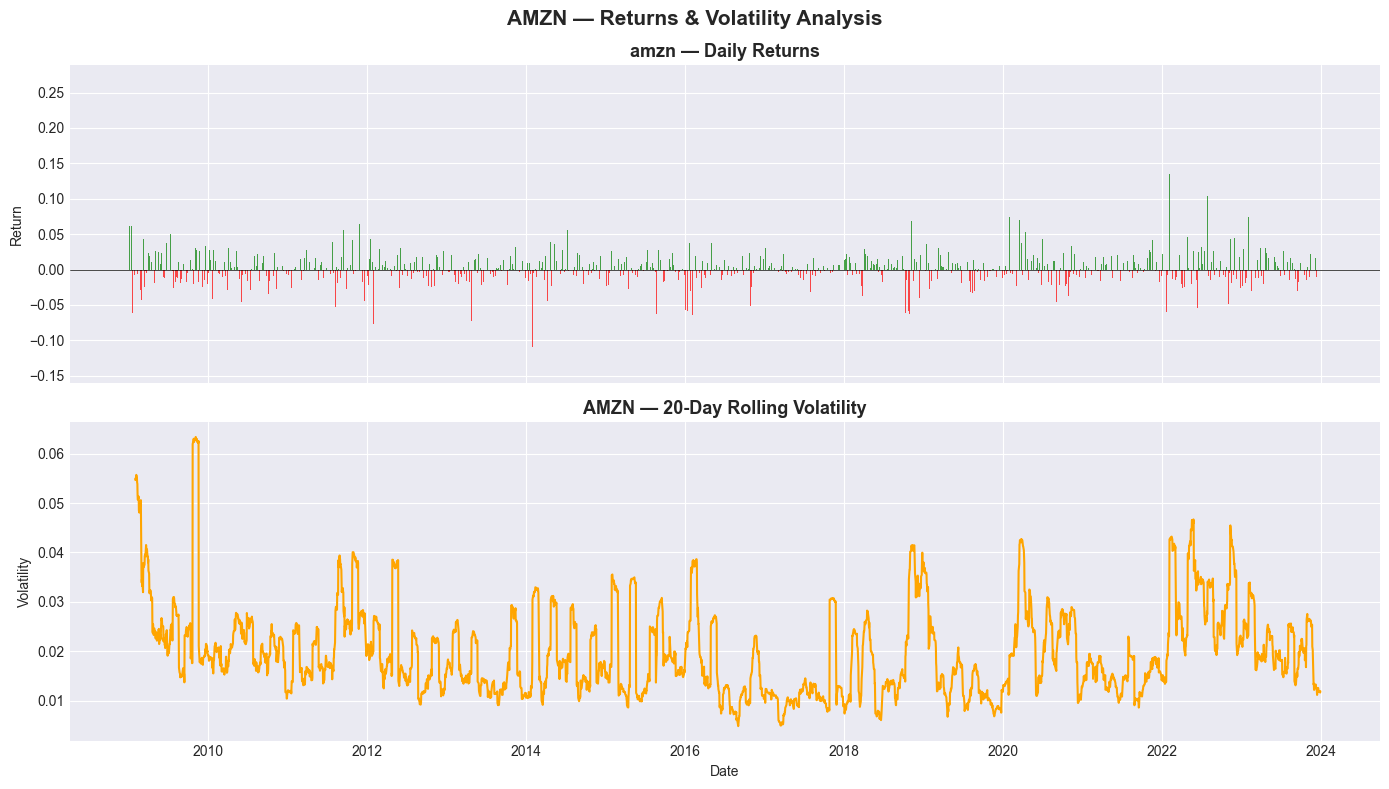

✅ Returns and volatility plot rendered!


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(amzn['Date'], amzn['Returns'],
            color=['green' if v >= 0 else 'red' for v in amzn['Returns'].fillna(0)],
            alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('amzn — Daily Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return')

axes[1].plot(amzn['Date'], amzn['Volatility_20'], color='orange', linewidth=1.5)
axes[1].set_title('AMZN — 20-Day Rolling Volatility', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.suptitle('AMZN — Returns & Volatility Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Returns and volatility plot rendered!")

## 9. QuantStats Performance Metrics

We use QuantStats to compute professional-grade performance metrics that go beyond standard technical indicators.

In [15]:
try:
    import quantstats as qs
    qs.extend_pandas()

    returns = amzn.set_index('Date')['Close'].pct_change()

    print("=== AMZN QuantStats Performance Metrics ===")
    print(f"Sharpe Ratio : {qs.stats.sharpe(returns):.2f}")
    print(f"Max Drawdown : {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Volatility   : {qs.stats.volatility(returns)*100:.2f}%")
    print(f"CAGR         : {qs.stats.cagr(returns)*100:.2f}%")
    print("✅ QuantStats metrics computed!")
except Exception as e:
    print(f"QuantStats error: {e}")

=== AMZN QuantStats Performance Metrics ===
Sharpe Ratio : 0.95
Max Drawdown : -56.15%
Volatility   : 34.65%
CAGR         : 30.82%
✅ QuantStats metrics computed!


## 10. Time Series Decomposition

We decompose the AMZN closing price into its core components:
- **Trend** — long-term direction of the price
- **Seasonal** — repeating patterns over time
- **Residual** — random noise remaining after removing trend and seasonality

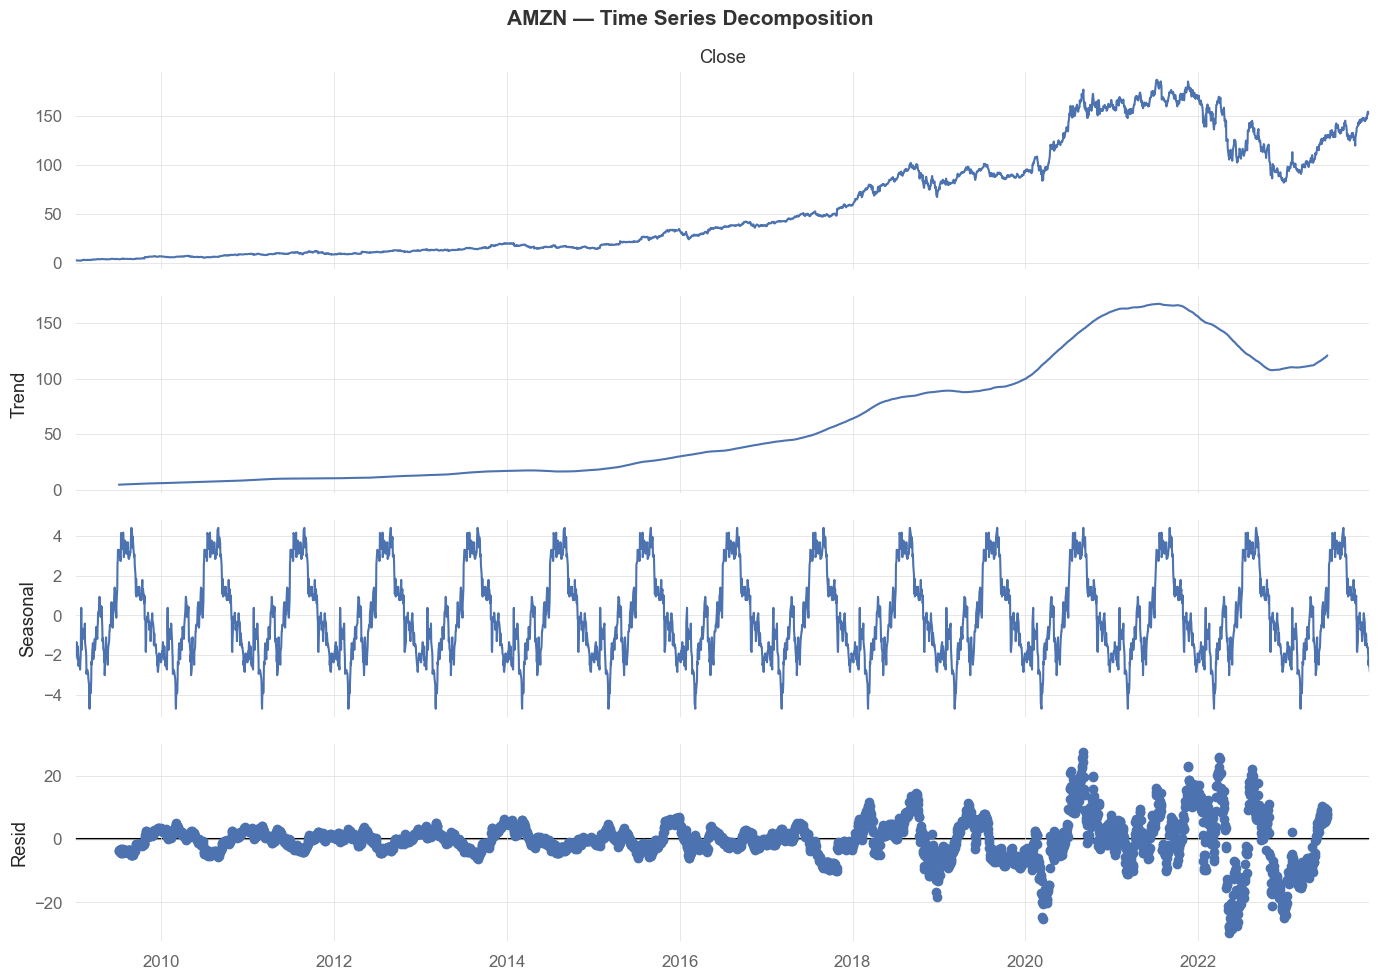

✅ Time series decomposition complete!


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

amzn_ts = amzn.set_index('Date')['Close']

result = seasonal_decompose(amzn_ts, model='additive', period=252)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle('AMZN — Time Series Decomposition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series decomposition complete!")

### 10.1 Decomposition Interpretation

The decomposition of AMZN's closing price into its four components provides the following insights:

- **Observed** — The original price series shows a strong upward trajectory from 2010 to 2022, with notable volatility and periodic pullbacks, reflecting AMZN's growth as a major technology stock.

- **Trend** — The trend component reveals a clear, sustained long-term upward direction. Starting near zero in 2010, the trend rises steadily to approximately 140 by 2022, confirming a powerful structural bull market for AMZN over the full period.

- **Seasonal** — The seasonal component displays regular, repeating annual patterns with consistent amplitude. Positive seasonal peaks and negative troughs occur with predictable timing each year, indicating that AMZN's stock price experiences recurring yearly fluctuations — likely tied to holiday sales (Q4 strength), earnings releases, or other calendar-driven events.

- **Residual** — The residual component captures random noise after removing trend and seasonality. Its fluctuations are centered around zero with relatively bounded variance, suggesting that the additive decomposition model fits the data well and that most meaningful patterns have been extracted by the trend and seasonal components.


## 11. Stationarity Analysis

A **stationary** time series has constant mean, variance, and covariance over time. Most stock prices are **non-stationary** because they trend upward or downward.

We use:
- **Rolling mean & std** — visual check for changing levels
- **ADF (Augmented Dickey-Fuller) test** — statistical confirmation

**Interpretation:**
- p-value < 0.05 → stationary
- p-value ≥ 0.05 → non-stationary

=== Stationarity Check: Original Price Series ===


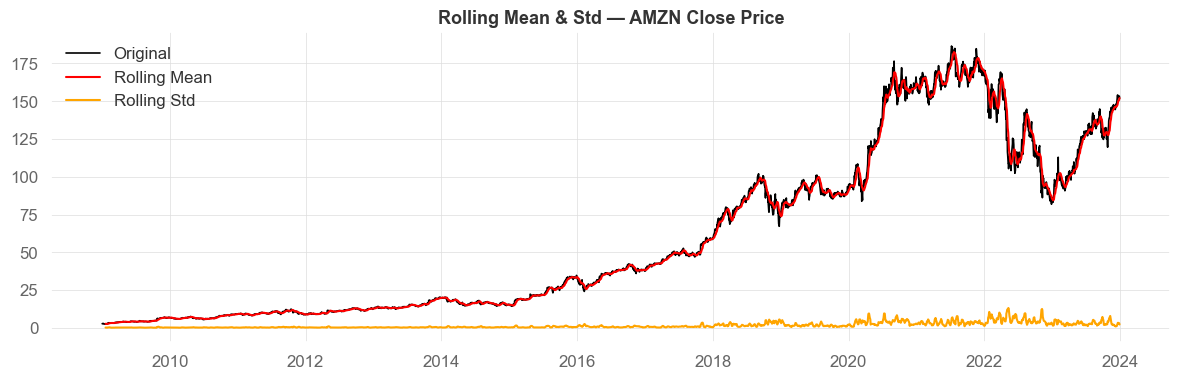

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -0.2734
p-value       : 0.9292
Conclusion: ⚠️  Non-Stationary (Fail to Reject Null Hypothesis)


In [17]:
print("=== Stationarity Check: Original Price Series ===")
check_stationarity(amzn_ts, title='AMZN Close Price')

### 11.1 First-Order Differencing

Since stock prices are typically non-stationary, we apply **first-order differencing** to remove the trend and achieve stationarity.

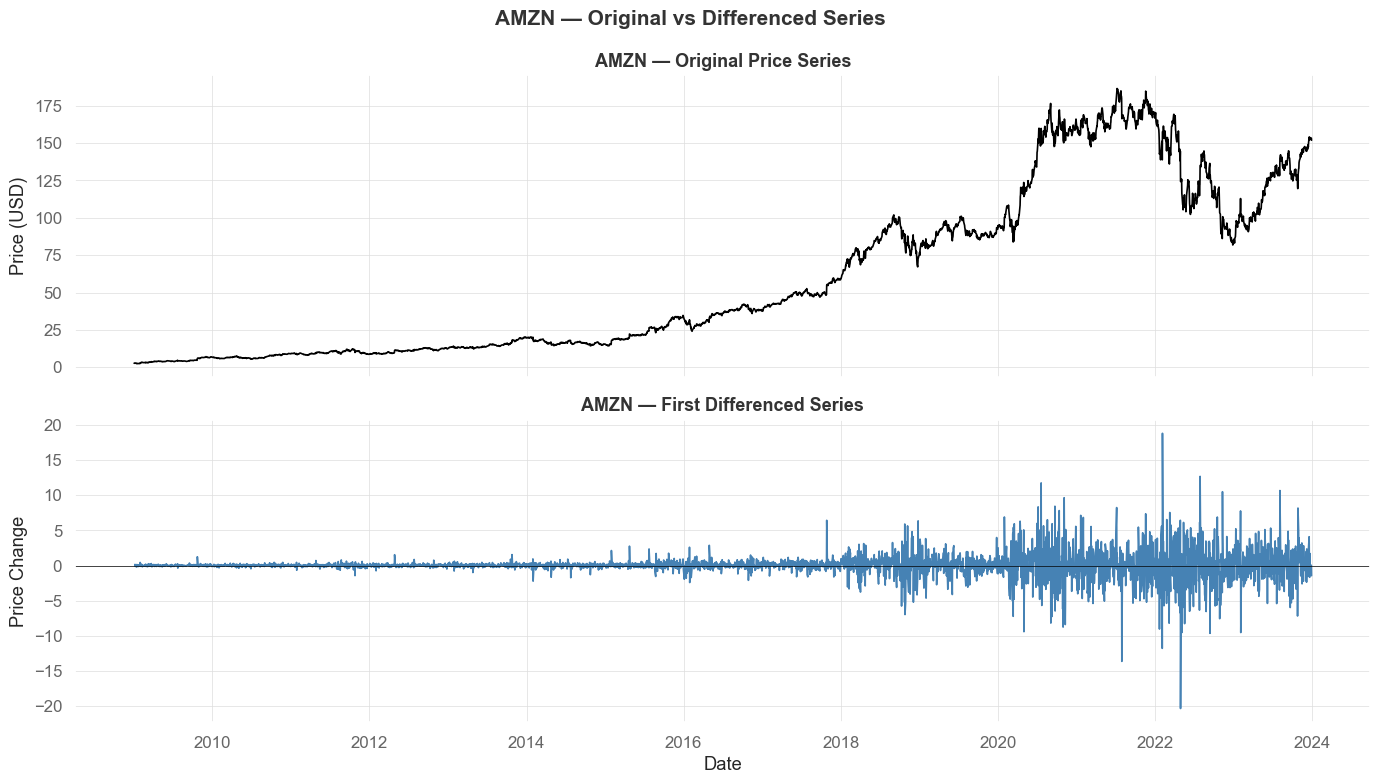


=== Stationarity Check: Differenced Series ===


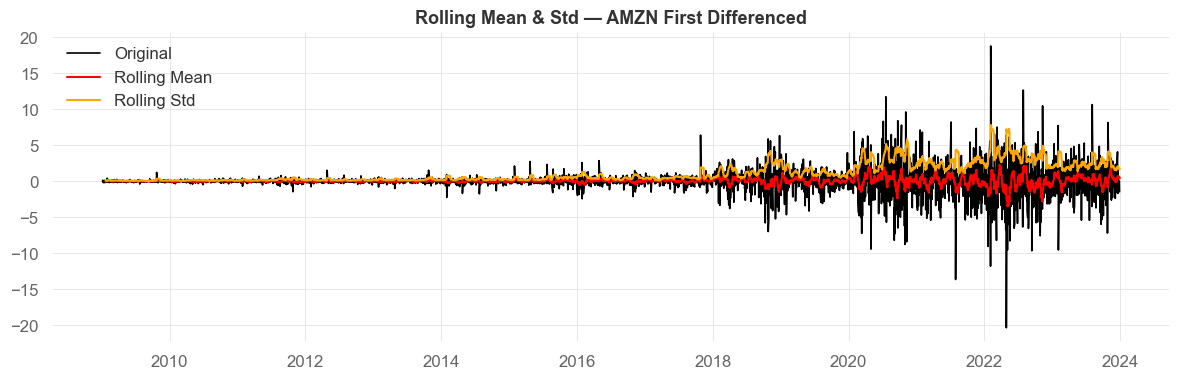

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -11.3918
p-value       : 0.0000
Conclusion: ✅ Stationary (Reject Null Hypothesis)


In [18]:
amzn_diff = amzn_ts.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(amzn_ts, color='black', linewidth=1.2)
axes[0].set_title('AMZN — Original Price Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(amzn_diff, color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('AMZN — First Differenced Series', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change')
axes[1].set_xlabel('Date')

plt.suptitle('AMZN — Original vs Differenced Series', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Stationarity Check: Differenced Series ===")
check_stationarity(amzn_diff, title='AMZN First Differenced')

## 12. Key Findings & Summary

In [19]:
print("=" * 55)
print("     AMZN TECHNICAL ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"""
📈 PRICE OVERVIEW
- Date range        : {amzn['Date'].min().date()} to {amzn['Date'].max().date()}
- Starting price    : ${amzn['Close'].iloc[0]:.2f}
- Ending price      : ${amzn['Close'].iloc[-1]:.2f}
- Price change      : {((amzn['Close'].iloc[-1] - amzn['Close'].iloc[0]) / amzn['Close'].iloc[0] * 100):.2f}%

📊 MOVING AVERAGES
- Final SMA 20      : ${amzn['SMA_20'].iloc[-1]:.2f}
- Final SMA 50      : ${amzn['SMA_50'].iloc[-1]:.2f}
- Final EMA 20      : ${amzn['EMA_20'].iloc[-1]:.2f}
- Final EMA 50      : ${amzn['EMA_50'].iloc[-1]:.2f}

📐 BOLLINGER BANDS
- BB Upper Band     : ${amzn['BB_Upper'].iloc[-1]:.2f}
- BB Middle Band    : ${amzn['BB_Middle'].iloc[-1]:.2f}
- BB Lower Band     : ${amzn['BB_Lower'].iloc[-1]:.2f}

⚡ MOMENTUM (RSI)
- Final RSI         : {amzn['RSI'].iloc[-1]:.2f}
- Average RSI       : {amzn['RSI'].mean():.2f}
- Overbought days   : {(amzn['RSI'] > 70).sum()}
- Oversold days     : {(amzn['RSI'] < 30).sum()}

📉 VOLATILITY & RETURNS
- Avg daily return  : {amzn['Returns'].mean():.4f}
- Max daily gain    : {amzn['Returns'].max():.4f}
- Max daily loss    : {amzn['Returns'].min():.4f}
""")
print("=" * 55)

     AMZN TECHNICAL ANALYSIS — KEY FINDINGS

📈 PRICE OVERVIEW
- Date range        : 2009-01-02 to 2023-12-29
- Starting price    : $2.72
- Ending price      : $151.94
- Price change      : 5490.14%

📊 MOVING AVERAGES
- Final SMA 20      : $149.82
- Final SMA 50      : $143.05
- Final EMA 20      : $150.21
- Final EMA 50      : $144.93

📐 BOLLINGER BANDS
- BB Upper Band     : $156.49
- BB Middle Band    : $149.82
- BB Lower Band     : $143.16

⚡ MOMENTUM (RSI)
- Final RSI         : 59.01
- Average RSI       : 54.57
- Overbought days   : 339
- Oversold days     : 48

📉 VOLATILITY & RETURNS
- Avg daily return  : 0.0013
- Max daily gain    : 0.2680
- Max daily loss    : -0.1405



## 13. Conclusion

The technical analysis of AMZN stock reveals an exceptionally strong long-term uptrend, with a price appreciation of **5490.14%** over the full analysis period from 2009 to 2023. The stock closed above both its 20-day and 50-day simple and exponential moving averages, confirming a **bullish trend** at the end of the period.

The RSI averaged **54.57** — moderately above neutral — with **339 overbought days** versus only **48 oversold days**, indicating sustained buying pressure throughout most of the period, though less extreme than some other high-growth technology names. The Bollinger Bands show the closing price ($151.94) sitting near the middle band ($149.82), suggesting the stock is trading within a normal range without immediate overbought or oversold extremes at the period's end.

The time series decomposition confirms a powerful upward trend with consistent and recurring annual seasonality, while the seasonal component validates that AMZN experiences predictable yearly patterns — likely driven by retail seasonality and earnings cycles. The residuals are well-behaved, confirming the decomposition model's appropriateness.

The average daily return of **0.13%** with a maximum single-day gain of **26.80%** and maximum loss of **-14.05%** reflects periods of significant volatility, including events such as earnings surprises, macroeconomic shifts, and broader market fluctuations.

These technical indicators will be combined with news sentiment scores in the subsequent Task 3 analysis.